# Image Preprocessing Pipeline for Machine Learning using OpenCV

This notebook teaches beginners how image preprocessing works before training machine learning and deep learning models.

You will learn:
- How images are represented
- Why preprocessing is important
- Basic preprocessing operations
- How preprocessing improves ML model performance



# What is Image Preprocessing?

Image preprocessing is the process of transforming raw images into a cleaner and more useful format before giving them to machine learning models.

## Why preprocessing is important
Machine learning models work better when:
- Images have the same size
- Noise is reduced
- Important features are highlighted
- Pixel values are normalized

## Typical preprocessing pipeline

1. Read image
2. Resize image
3. Convert color space
4. Remove noise
5. Detect important features
6. Normalize pixel values
7. Convert image into tensor/array for ML models



# Step 1 — Import Libraries

We use:
- OpenCV for image processing
- NumPy for numerical operations
- Matplotlib for displaying images


In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt



# Step 2 — Read an Image

Images are stored as matrices of pixels.

OpenCV loads images as NumPy arrays.

## Understanding image dimensions

A color image has:
- Height
- Width
- Channels (Blue, Green, Red)

Example:
(300, 400, 3)

means:
- Height = 300 pixels
- Width = 400 pixels
- 3 color channels


Image Shape: (430, 710, 3)


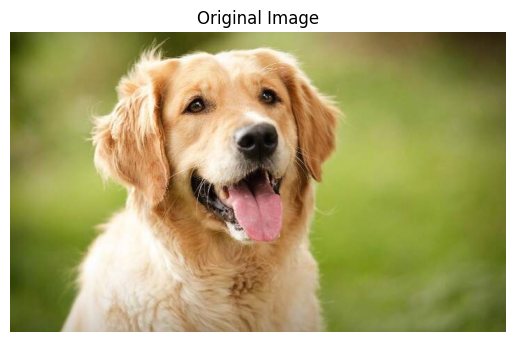

In [2]:

# Replace with your image path
img = cv2.imread("/Users/rukku/Downloads/golden-retriever-tongue-out.jpj")

# Check if image loaded successfully
print("Image Shape:", img.shape)

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()



# Step 3 — Resize the Image

Machine learning models require fixed-size inputs.

For example:
- CIFAR-10 uses 32×32 images
- Many CNN models use 224×224 images

Resizing ensures all images have consistent dimensions.


Resized Shape: (224, 224, 3)


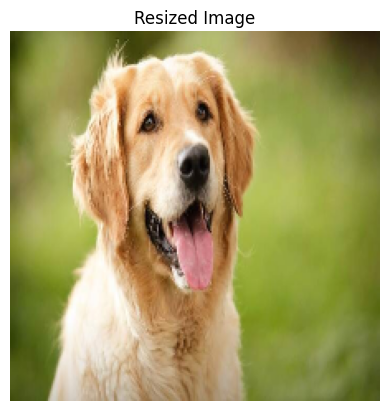

In [3]:

resized = cv2.resize(img_rgb, (224, 224))

print("Resized Shape:", resized.shape)

plt.imshow(resized)
plt.title("Resized Image")
plt.axis("off")
plt.show()



# Step 4 — Convert Image to Grayscale

Grayscale images contain only intensity information.

Benefits:
- Reduces computational complexity
- Uses less memory
- Useful when color is not important

A grayscale image has only one channel.


Grayscale Shape: (224, 224)


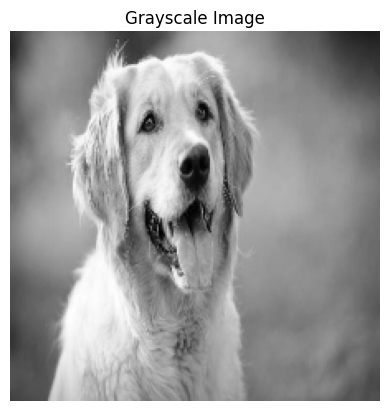

In [4]:

gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

print("Grayscale Shape:", gray.shape)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()



# Step 5 — Apply Gaussian Blur

Real-world images often contain noise.

Gaussian blur smooths the image and removes unwanted noise.

This helps ML models focus on important patterns instead of random variations.


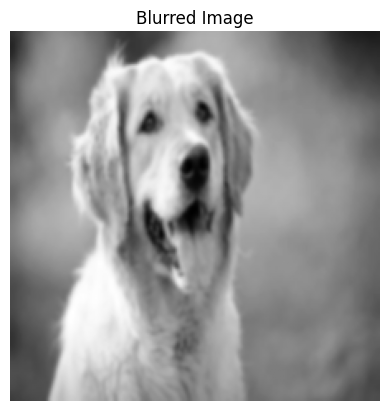

In [5]:

blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.imshow(blur, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")
plt.show()



# Step 6 — Edge Detection

Edges help identify object boundaries.

The Canny edge detector highlights:
- Shapes
- Boundaries
- Important structures

This is useful in:
- Object detection
- Medical imaging
- OCR systems


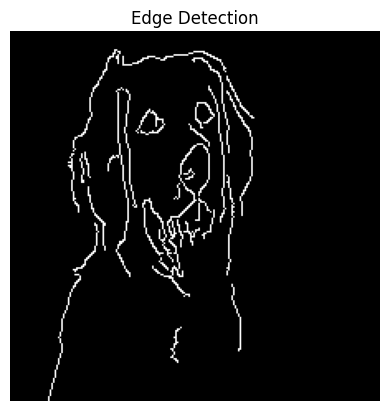

In [6]:

edges = cv2.Canny(blur, 100, 200)

plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")
plt.show()



# Step 7 — Thresholding

Thresholding converts an image into binary form.

Pixel values become:
- 0 (black)
- 255 (white)

This is useful for:
- OCR
- Segmentation
- Document analysis


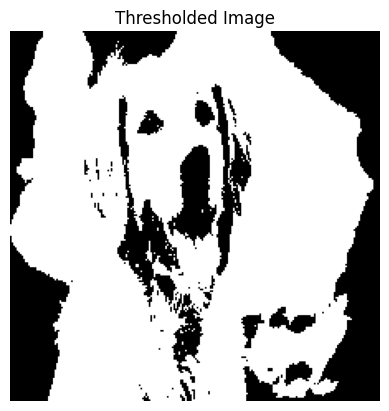

In [7]:

_, threshold = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(threshold, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()



# Step 8 — Normalize Pixel Values

Machine learning models train better when values are scaled.

Original pixel range:
0 to 255

Normalized range:
0 to 1

Normalization improves:
- Training stability
- Convergence speed
- Numerical efficiency


In [8]:

normalized = gray / 255.0

print("Minimum Value:", normalized.min())
print("Maximum Value:", normalized.max())


Minimum Value: 0.011764705882352941
Maximum Value: 1.0



# Step 9 — Complete Preprocessing Pipeline

Now we combine all preprocessing operations together.

Pipeline:
1. Read image
2. Resize
3. Grayscale conversion
4. Blur
5. Edge detection
6. Normalize


Final Shape: (224, 224)


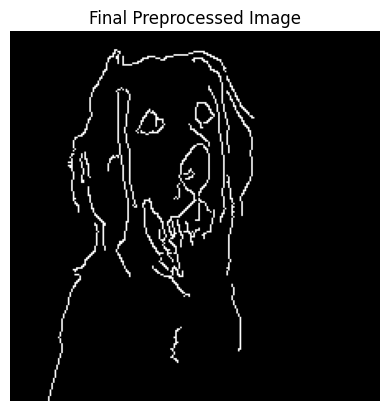

In [9]:

# Read image
img = cv2.imread("/Users/rukku/Downloads/golden-retriever-tongue-out.jpj")

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize
img = cv2.resize(img, (224, 224))

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Edge detection
edges = cv2.Canny(blur, 100, 200)

# Normalize
processed = edges / 255.0

print("Final Shape:", processed.shape)

plt.imshow(processed, cmap="gray")
plt.title("Final Preprocessed Image")
plt.axis("off")
plt.show()



# Summary

In this notebook you learned:

| Step | Purpose |
|---|---|
| Read image | Load image into memory |
| Resize | Standardize image size |
| Grayscale | Reduce complexity |
| Blur | Remove noise |
| Edge detection | Highlight important structures |
| Thresholding | Binary segmentation |
| Normalize | Improve ML training |

